Este conjunto de datos contiene información sobre reservas de hoteles hechas a lo largo del tiempo, incluyendo detalles sobre los clientes, el comportamiento de reserva y la probabilidad de cancelación.

Es ideal para aplicar modelos de clasificación binaria, donde el objetivo puede ser predecir si una reserva será cancelada (`is_canceled = 1`) o no (`is_canceled = 0`).

## Variables

| Nombre Variable                  | Descripción                                              |
| -------------------------------- | -------------------------------------------------------- |
| `hotel`                          | Tipo de hotel: City Hotel o Resort Hotel                 |
| `is_canceled`                    | Variable objetivo: 1 si fue cancelado, 0 si no           |
| `lead_time`                      | Días entre la reserva y la fecha de llegada              |
| `arrival_date_year`              | Año de llegada                                           |
| `arrival_date_month`             | Mes de llegada                                           |
| `arrival_date_week_number`       | Número de la semana del año                              |
| `arrival_date_day_of_month`      | Día del mes de llegada                                   |
| `stays_in_weekend_nights`        | Noches de fin de semana reservadas                       |
| `stays_in_week_nights`           | Noches entre semana reservadas                           |
| `adults`                         | Número de adultos                                        |
| `children`                       | Número de niños                                          |
| `babies`                         | Número de bebés                                          |
| `meal`                           | Tipo de comida reservada                                 |
| `country`                        | País de origen del cliente                               |
| `market_segment`                 | Canal de marketing (online, offline, grupos...)          |
| `distribution_channel`           | Canal de distribución (directo, TA/TO...)                |
| `is_repeated_guest`              | 1 si el cliente ha estado anteriormente                  |
| `previous_cancellations`         | Nº de cancelaciones anteriores                           |
| `previous_bookings_not_canceled` | Nº de reservas previas no canceladas                     |
| `reserved_room_type`             | Tipo de habitación reservada                             |
| `assigned_room_type`             | Tipo de habitación asignada                              |
| `booking_changes`                | Nº de cambios en la reserva                              |
| `deposit_type`                   | Tipo de depósito: No Deposit, Refundable, etc.           |
| `agent`                          | ID del agente (puede ser nulo)                           |
| `company`                        | ID de la empresa (puede ser nulo)                        |
| `days_in_waiting_list`           | Días en lista de espera                                  |
| `customer_type`                  | Tipo de cliente: Transient, Group, etc.                  |
| `adr`                            | Average Daily Rate (precio promedio por noche)           |
| `required_car_parking_spaces`    | Plazas de parking solicitadas                            |
| `total_of_special_requests`      | Nº de peticiones especiales                              |
| `reservation_status`             | Estado final de la reserva: Check-Out, Canceled, No-Show |
| `reservation_status_date`        | Fecha en que se actualizó el estado                      |

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

In [ ]:
df = pd.read_csv("../../data/raw/dataset_practica_final.csv")

# Quitamos las variables irrelevantes para el modelo, ya que no aportan información útil para la predicción de la variable objetivo.
irrelevant_columns = ['meal', 'total_of_special_requests', 'required_car_parking_spaces', 'days_in_waiting_list', 'arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month', 'arrival_date_week_number', 'reservation_status', 'reservation_status_date', 'assigned_room_type', 'reservation_status', 'reservation_status_date', 'assigned_room_type', 'country']
df_without_irrelevant = df.drop(columns=irrelevant_columns)

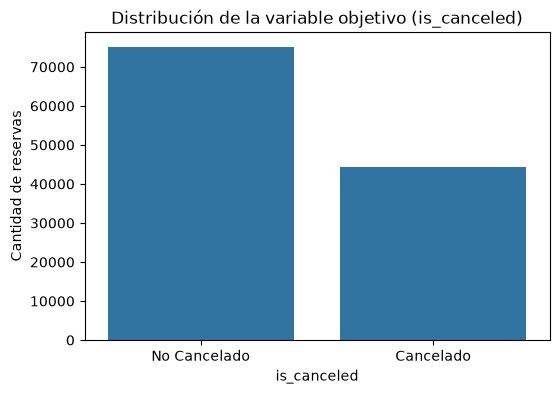

In [ ]:
# Distribución de la variable objetivo (is_canceled)
plt.figure(figsize=(6, 4))
sns.countplot(x='is_canceled', data=df_without_irrelevant)
plt.title('Distribución de la variable objetivo (is_canceled)')
plt.xticks([0, 1], ['No Cancelado', 'Cancelado'])
plt.ylabel('Cantidad de reservas')
plt.show()

In [ ]:
# Seteamos la variable objetivo
target_column = 'is_canceled'
target = df_without_irrelevant[target_column]
df_preprocessed = df_without_irrelevant.drop(columns=[target_column])

# Imputamos los valores faltantes en las columnas numéricas
numeric_columns_with_naan = ['children', 'agent', 'company']
imputer_numerico = SimpleImputer(strategy="mean")
df_preprocessed[numeric_columns_with_naan] = imputer_numerico.fit_transform(df_preprocessed[numeric_columns_with_naan])

# Codificación de variables categóricas
categorical_columns = df_preprocessed.select_dtypes(include=['object']).columns.tolist()
encoder = OneHotEncoder(sparse_output=False)
df_encoded = pd.DataFrame(
    encoder.fit_transform(df_preprocessed[categorical_columns]),
    columns=encoder.get_feature_names_out(categorical_columns)
)
df_encoded.columns = df_encoded.columns.str.lower()
df_preprocessed = pd.concat(
    [df_preprocessed.drop(columns=categorical_columns), df_encoded],
    axis=1)

# Escalado de variables numéricas
scaler = StandardScaler()
df_preprocessed[df_preprocessed.columns] = scaler.fit_transform(df_preprocessed[df_preprocessed.columns])

df_preprocessed[target_column] = target.values

# Reemplzamos los valores numéricos de la columna 'target' por los nombres de las clases
dict_canceled = {
    'No cancelado' : 0,
    'Cancelado' : 1
}

df_preprocessed[target_column] = df_preprocessed[target_column].replace(dict_canceled)

df_preprocessed.describe().transpose()

/var/folders/p6/rzkvpch94kn4zdcqnkvnvhg80000gn/T/ipykernel_6842/3921229208.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df_preprocessed.select_dtypes(include=['object']).columns.tolist()


,count,mean,std,min,25%,50%,75%,max
lead_time,119390.0,3.428031e-17,1.000004,-0.973319,-8.048782e-01,-3.276301e-01,5.239303e-01,5.923385
stays_in_weekend_nights,119390.0,1.295034e-16,1.000004,-0.928890,-9.288904e-01,7.250220e-02,1.073895e+00,18.097569
stays_in_week_nights,119390.0,-1.523569e-17,1.000004,-1.310240,-7.862072e-01,-2.621744e-01,2.618584e-01,24.891398
adults,119390.0,6.665616e-18,1.000004,-3.204792,2.478973e-01,2.478973e-01,2.478973e-01,91.744169
children,119390.0,4.380262e-17,1.000004,-0.260668,-2.606677e-01,-2.606677e-01,-2.606677e-01,24.830092
babies,119390.0,2.475800e-17,1.000004,-0.081579,-8.157926e-02,-8.157926e-02,-8.157926e-02,102.550120
is_repeated_guest,119390.0,-1.142677e-17,1.000004,-0.181560,-1.815604e-01,-1.815604e-01,-1.815604e-01,5.507809
previous_cancellations,119390.0,0.000000e+00,1.000004,-0.103180,-1.031795e-01,-1.031795e-01,-1.031795e-01,30.690364
previous_bookings_not_canceled,119390.0,1.523569e-17,1.000004,-0.091555,-9.155477e-02,-9.155477e-02,-9.155477e-02,47.990808
booking_changes,119390.0,3.618477e-17,1.000004,-0.338990,-3.389899e-01,-3.389899e-01,-3.389899e-01,31.854646


In [6]:
# Mapa de calor de correlación
plt.figure(figsize=(10, 8))
corr = df_preprocessed.corr()[['is_canceled']].sort_values(by='is_canceled', ascending=False)
sns.heatmap(corr.head(15), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Top variables correlacionadas con la cancelación')
plt.show()

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/davidgarciavaleriano/Pontia/Proyectos/pontia-ml-proyecto-final/.venv/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3823, in run_code
  File "/var/folders/p6/rzkvpch94kn4zdcqnkvnvhg80000gn/T/ipykernel_7239/3879982586.py", line 2, in <module>
    plt.figure(figsize=(10, 8))
    ^^^
NameError: name 'plt' is not defined

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/davidgarciavaleriano/Pontia/Proyectos/pontia-ml-proyecto-final/.venv/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 2279, in showtraceback
  File "/Users/davidgarciavaleriano/Pontia/Proyectos/pontia-ml-proyecto-final/.venv/lib/python3.11/site-packages/IPython/core/ultratb.py", line 1300, in structured_traceback
  File "/Users/davidgarciavaleriano/Pontia/Proyectos/pontia-ml-proyecto-final/.venv/lib/python3.11/site-packages/IPython/core/ultratb.py", line 1166, in s

In [45]:
df_preprocessed.to_csv("../../data/processed/dataset_practica_final_preprocessed.csv", index=False)